# GARCH Models for Global Equity Indices

## 1. Project objective

Estimate GARCH-family volatility models for four major equity indices and **compare how
persistent volatility is across markets**.

| Index | Ticker | Region |
|---|---|---|
| S&P 500 | `^GSPC` | United States |
| EURO STOXX 50 | `^STOXX50E` | Euro area |
| Nikkei 225 | `^N225` | Japan |
| FTSE 100 | `^FTSE` | United Kingdom |

The questions the project sets out to answer:

1. Which index is the most volatile?
2. Which index has the **most persistent** volatility?
3. Do crisis periods show clear volatility spikes?
4. Does a Student-t GARCH fit better than normal errors?
5. Are the standardised residuals still autocorrelated?
6. How different are volatility dynamics across regions?

## 2. Data sources

Daily adjusted closing prices from **Yahoo Finance** via the `yfinance` package,
cached locally in `data/raw/`. Sample starts 2000-01-01 where available.

## 3. Methodology

Log returns scaled by 100, a constant mean, and conditional variance modelled as

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

estimated by maximum likelihood. **Persistence** is $\alpha + \beta$: how much of
today's variance carries into tomorrow. Values near 1 mean shocks decay slowly.
Models are compared on AIC/BIC and judged on residual diagnostics and an
out-of-sample VaR backtest.

---
## 4. Import libraries

All the analysis logic lives in `src/` so the notebook stays readable and the same
code backs the report. `src.run_analysis` reproduces every figure and table in one go.

In [1]:
import sys
from pathlib import Path

# The notebook lives in notebooks/, so add the project root to the path.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import config as C
from src import data as D
from src import eda as E
from src import models as M
from src import diagnostics as G
from src import plotting as P
from src import var_backtest as V

P.apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("Setup is working!")
print("Indices:", ", ".join(f"{v} ({k})" for k, v in C.INDICES.items()))

Setup is working!
Indices: S&P 500 (^GSPC), EURO STOXX 50 (^STOXX50E), Nikkei 225 (^N225), FTSE 100 (^FTSE)


---
## 5. Load data

`load_prices()` downloads each index once and caches it as a CSV, so re-running the
notebook is instant and works offline. Pass `force=True` to refresh.

In [2]:
prices = D.load_prices()
prices.tail()

,^GSPC,^STOXX50E,^N225,^FTSE
date,,,,
2026-07-22,"7,498.9600","6,316.9902","66,115.6016","10,717.0000"
2026-07-23,"7,408.2998","6,210.1699","66,422.6016","10,639.2002"
2026-07-27,"7,413.1802","6,282.2100","64,931.1914","10,781.7998"
2026-07-28,"7,428.7798",NaN,NaN,NaN
2026-07-29,NaN,NaN,"61,689.8594",NaN


### Note on sample coverage

Yahoo only serves EURO STOXX 50 from 2007, so it has a shorter history than the other
three. That matters for a persistence *comparison*, so section 10 refits every model on
the common window as a robustness check.

In [3]:
returns = D.log_returns(prices)
returns, flagged = D.clean_returns(returns)
print("Implausible observations dropped:", flagged or "none")

coverage = D.coverage_table(prices, returns)
coverage

Implausible observations dropped: none


,Ticker,Region,Start,End,Price obs,Return obs,Years
Index,,,,,,,
S&P 500,^GSPC,United States,2000-01-03,2026-07-28,6680,6679,26.6000
EURO STOXX 50,^STOXX50E,Euro area,2007-03-30,2026-07-27,4841,4840,19.3000
Nikkei 225,^N225,Japan,2000-01-04,2026-07-29,6506,6505,26.6000
FTSE 100,^FTSE,United Kingdom,2000-01-04,2026-07-27,6709,6708,26.6000


---
## 6. Clean data and build returns

Two conventions, both deliberate:

**Log returns.** $r_t = 100 \times \ln(P_t / P_{t-1})$. Log returns add across time,
which is what the variance recursion assumes.

**The factor of 100.** GARCH is estimated by numerical maximum likelihood. Raw daily
returns are around 0.01, so $\omega$ lands near $10^{-6}$ and the optimiser struggles.
Scaling to percent puts every parameter near order 1.

**Each index keeps its own calendar.** Tokyo, London, New York and the euro area have
different holidays. Forward-filling across a holiday would invent a zero return and
distort the very clustering we are trying to measure, so returns are computed per index
on that index's own trading days.

In [4]:
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
^GSPC,"6,679.0000",0.0244,1.2150,-12.7652,-0.4729,0.0641,0.5878,10.9572
^STOXX50E,"4,840.0000",0.0084,1.3755,-13.2405,-0.6096,0.0412,0.6760,10.4376
^N225,"6,505.0000",0.0181,1.4783,-13.2341,-0.7058,0.0552,0.8084,13.2346
^FTSE,"6,708.0000",0.0072,1.1280,-11.5117,-0.4907,0.0500,0.5597,9.3842


---
## 7. Exploratory data analysis

### 7.1 Summary statistics

The four numbers that matter for volatility modelling: annualised volatility (how risky),
skew (are crashes bigger than rallies), excess kurtosis (how fat the tails are), and the
Jarque-Bera test of normality.

In [5]:
summary = E.summary_statistics(returns)
summary[["Obs", "Ann. return (%)", "Ann. vol (%)", "Skew", "Excess kurtosis", "Min (%)", "Max (%)", "JB p"]]

,Obs,Ann. return (%),Ann. vol (%),Skew,Excess kurtosis,Min (%),Max (%),JB p
Index,,,,,,,,
S&P 500,6679,6.1508,19.2871,-0.3486,10.6474,-12.7652,10.9572,0.0000
EURO STOXX 50,4840,2.1199,21.8352,-0.3027,7.6702,-13.2405,10.4376,0.0000
Nikkei 225,6505,4.5617,23.4680,-0.3807,6.8798,-13.2341,13.2346,0.0000
FTSE 100,6708,1.8064,17.9062,-0.3679,8.3573,-11.5117,9.3842,0.0000


Every index is **negatively skewed** with **large positive excess kurtosis**, and
Jarque-Bera rejects normality at any sensible level. A normal distribution has excess
kurtosis 0; these run from 6.9 to 10.6. This is the first argument for Student-t
innovations.

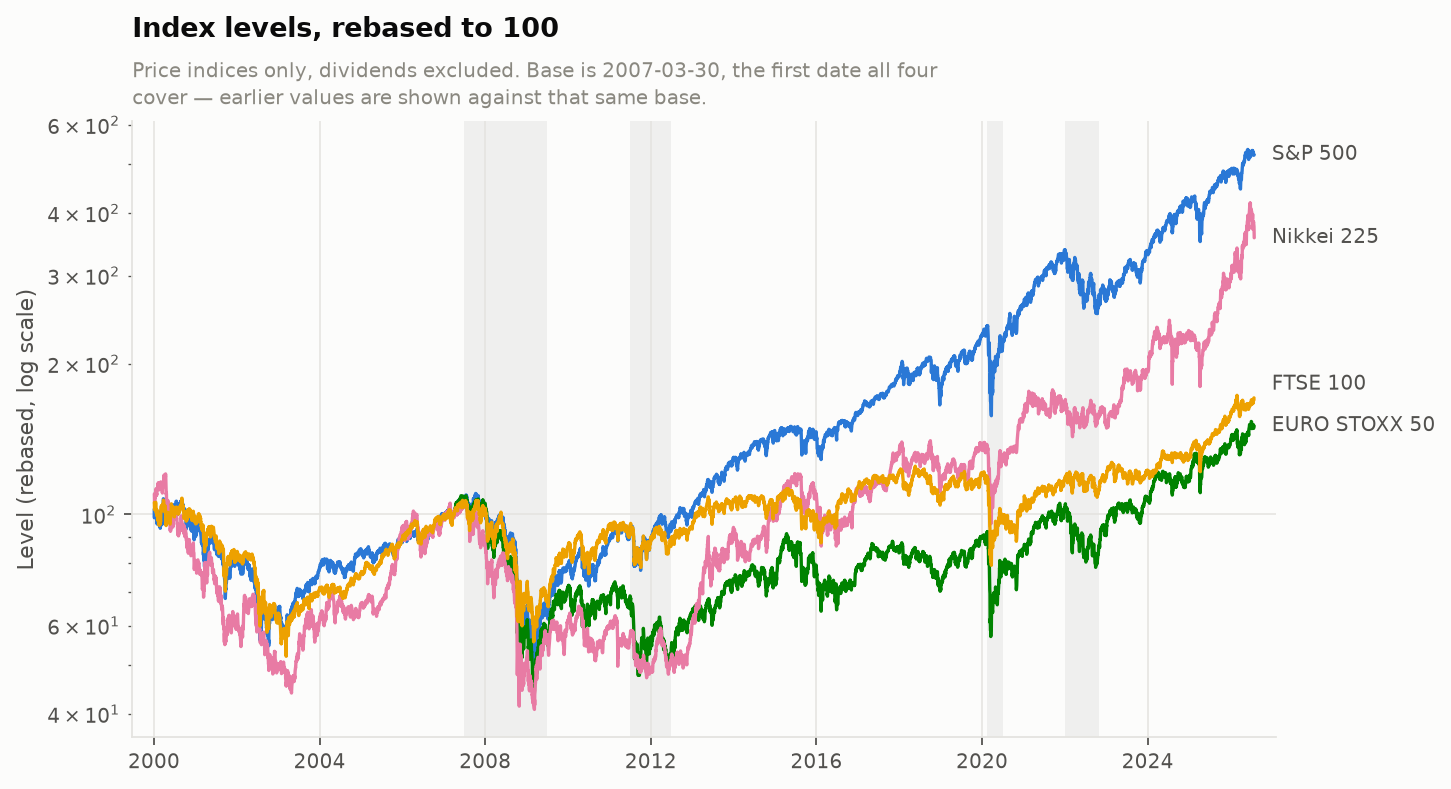

In [6]:
display(Image(E.plot_normalised_prices(prices)))

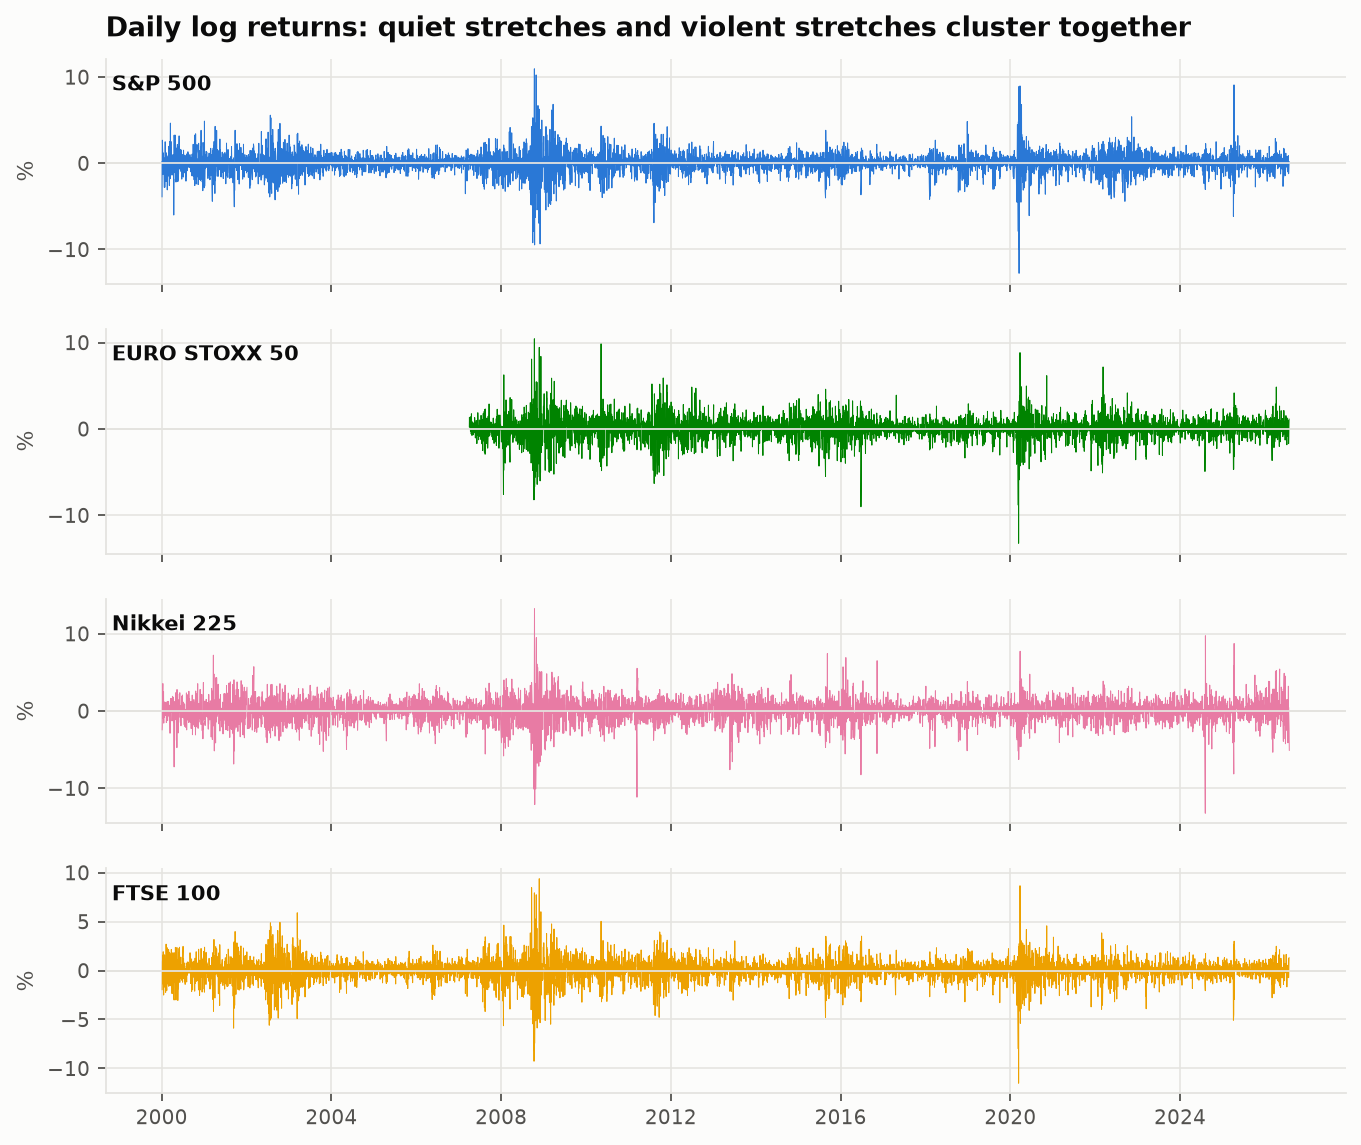

In [7]:
display(Image(E.plot_return_series(returns)))

### 7.2 Volatility clustering

The return-series chart shows the defining feature: **big moves follow big moves**. The
formal test is Ljung-Box. Returns themselves should be close to unpredictable; their
squares should not be.

In [8]:
E.volatility_clustering_table(returns)

,LB(10) returns,p (returns),LB(10) squared,p (squared),ACF |r| lag1
Index,,,,,
S&P 500,97.1310,0.0000,"6,096.4039",0.0000,0.2888
EURO STOXX 50,33.5417,0.0002,"1,877.1125",0.0000,0.2103
Nikkei 225,17.6385,0.0614,"3,221.0180",0.0000,0.2203
FTSE 100,68.0331,0.0000,"4,128.8300",0.0000,0.2838


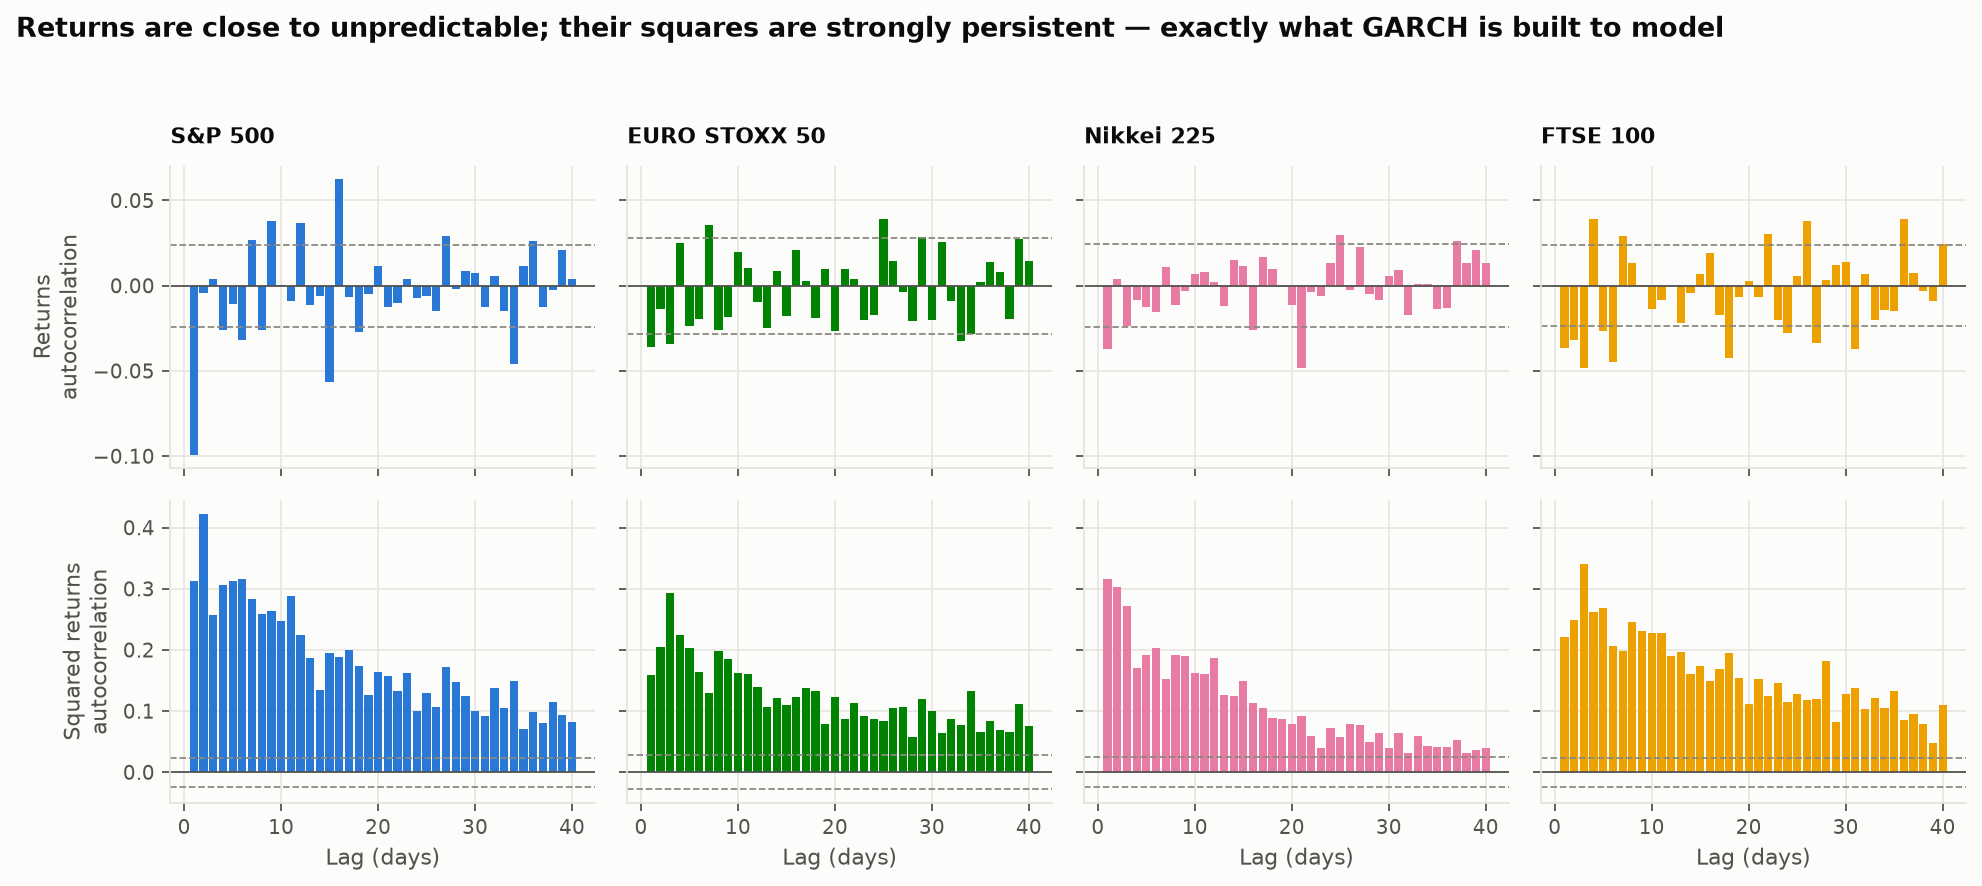

In [9]:
display(Image(E.plot_acf_panel(returns)))

The squared-return Ljung-Box statistics are enormous (p < 0.001 everywhere) while the
return statistics are small. **Volatility is predictable even though direction is not** —
which is precisely the gap GARCH fills.

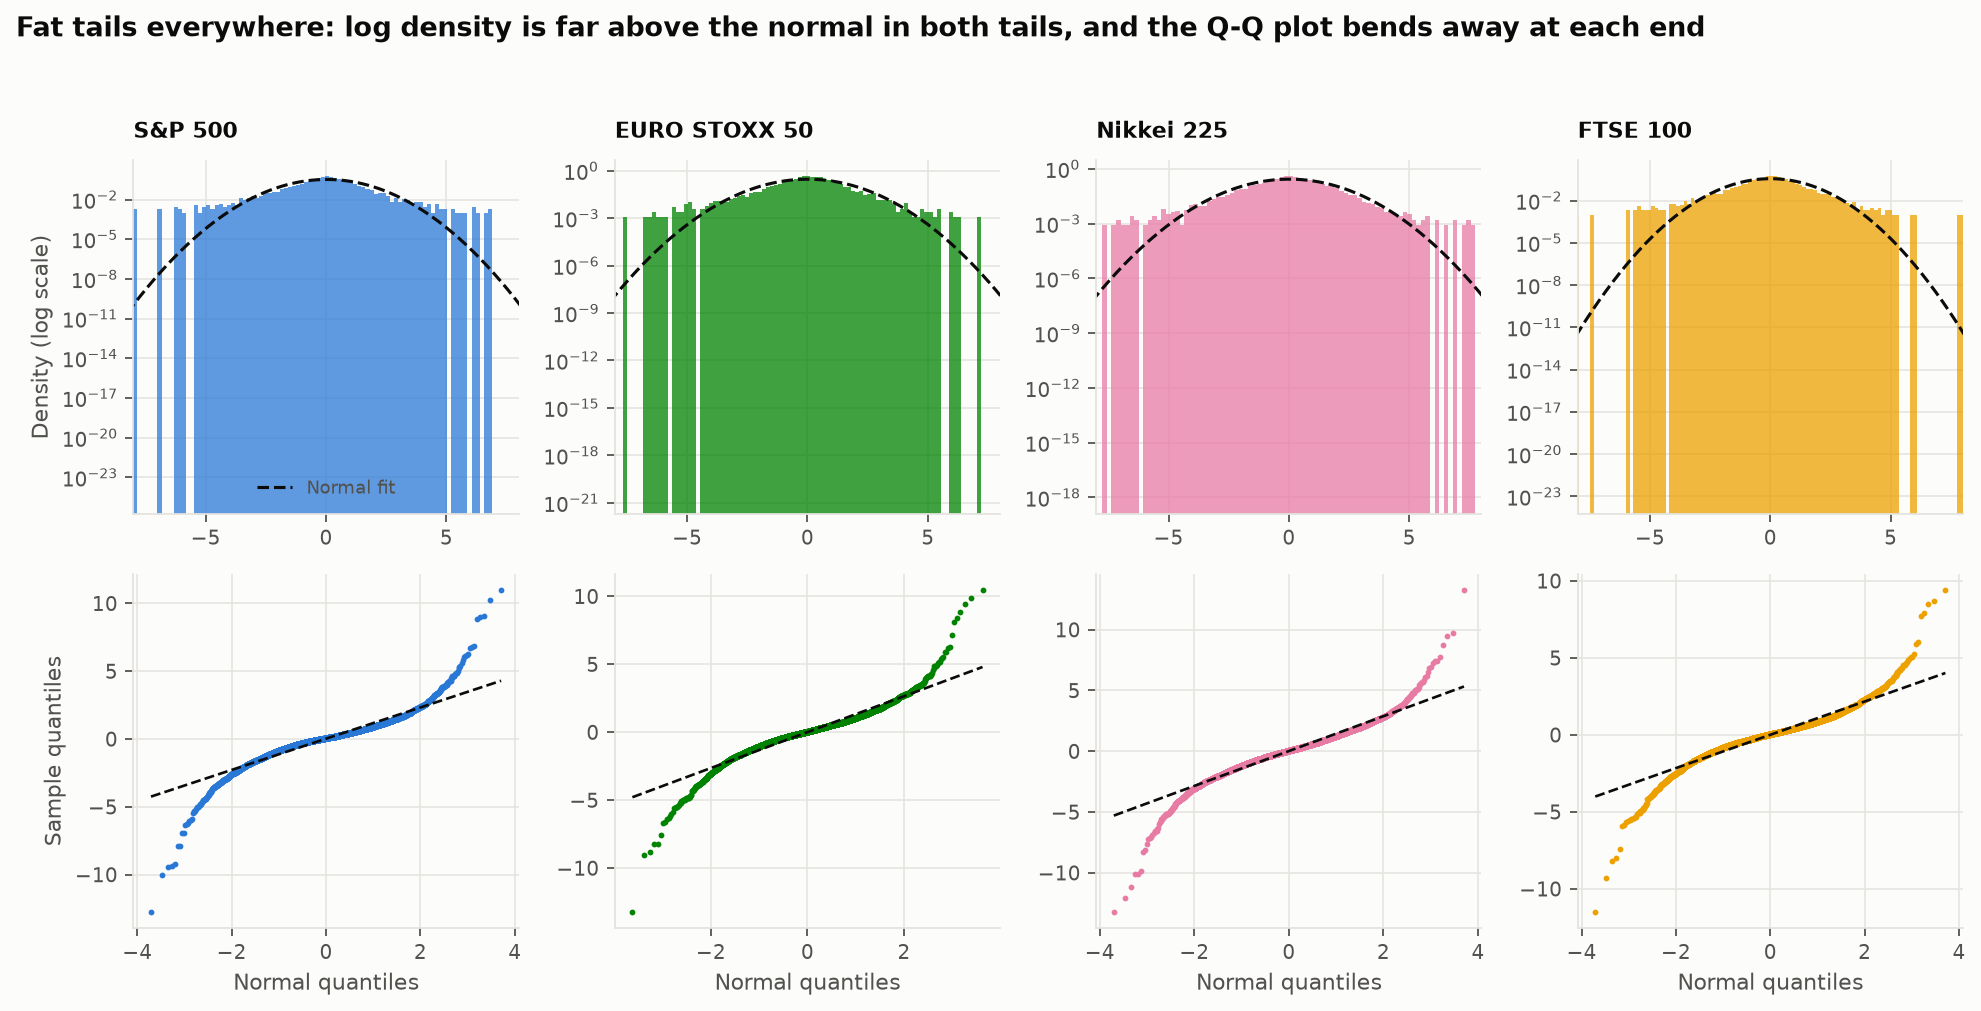

In [10]:
display(Image(E.plot_return_distributions(returns)))

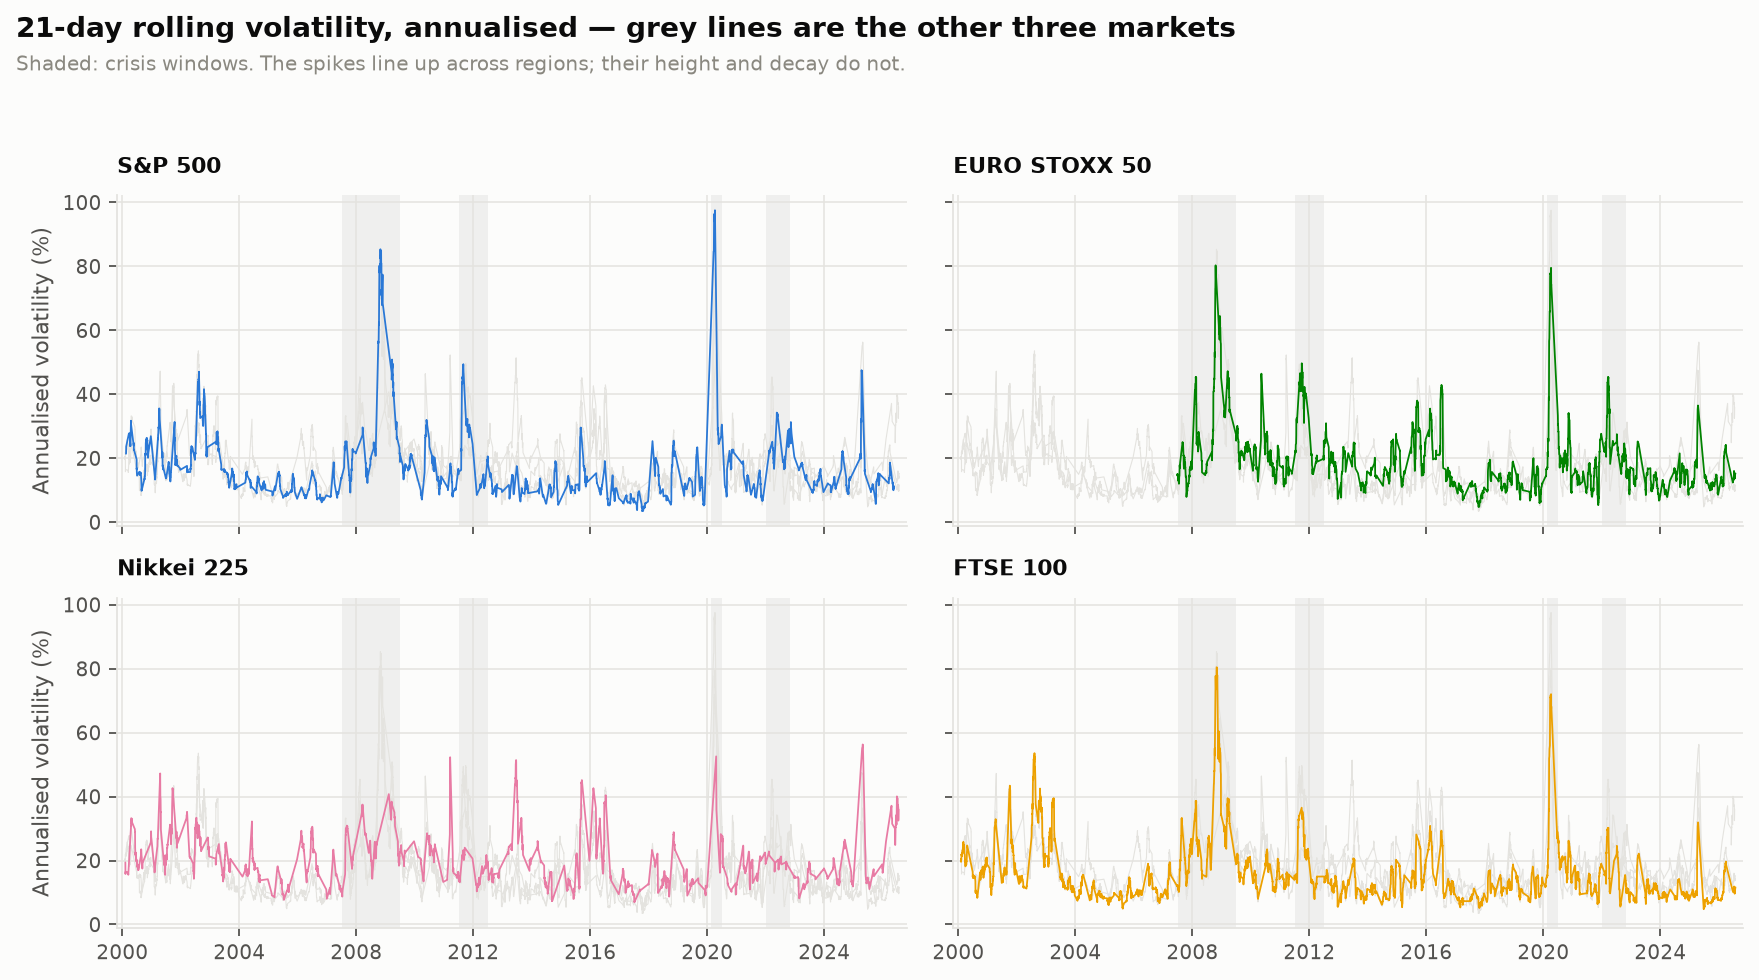

In [11]:
display(Image(E.plot_rolling_volatility(returns)))

### 7.3 Stationarity

GARCH assumes the return series is stationary. Augmented Dickey-Fuller tests the null of
a unit root.

In [12]:
E.stationarity_table(returns)

,ADF stat,p-value,Lags used,Crit. 1%,Crit. 5%,Stationary at 5%
Index,,,,,,
S&P 500,-19.6748,0.0000,17,-3.4313,-2.8620,Yes
EURO STOXX 50,-22.5270,0.0000,9,-3.4317,-2.8621,Yes
Nikkei 225,-83.6281,0.0000,0,-3.4314,-2.8620,Yes
FTSE 100,-14.8534,0.0000,35,-3.4313,-2.8620,Yes


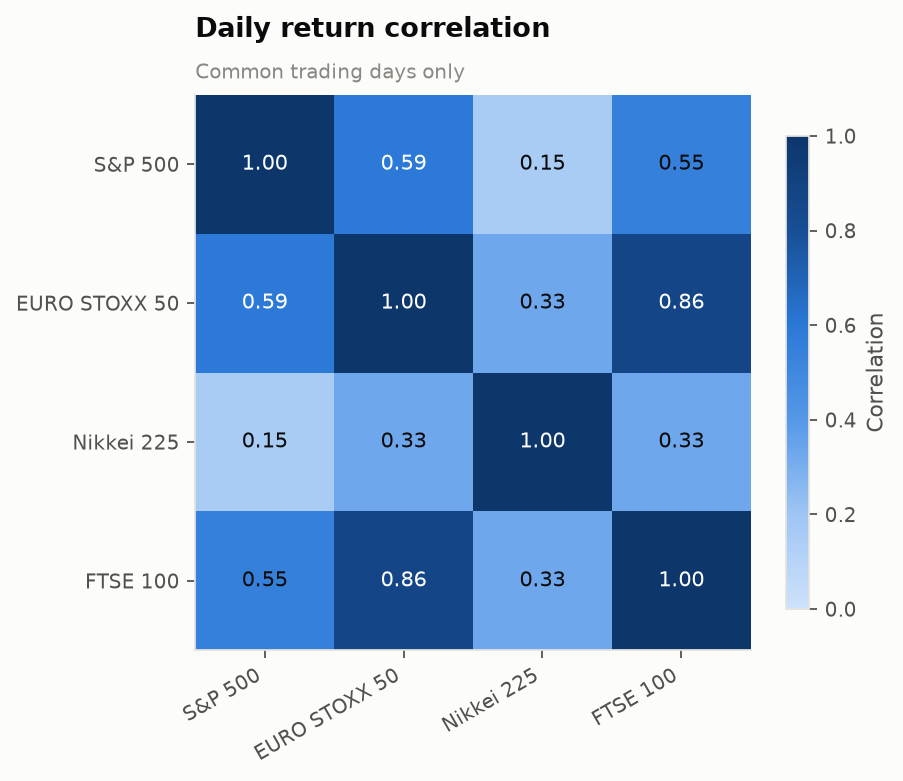

In [13]:
corr = E.correlation_matrix(returns)
display(Image(E.plot_correlation_heatmap(corr)))

---
## 8. Model building

Five specifications per index:

| Model | Variance equation | What it adds |
|---|---|---|
| GARCH(1,1)-Normal | $\sigma_t^2 = \omega + \alpha\varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2$ | the baseline |
| GARCH(1,1)-t | same | fat-tailed innovations |
| GARCH(1,1)-skew-t | same | fat tails **and** asymmetric innovations |
| GJR-GARCH(1,1)-t | $+\ \gamma\varepsilon_{t-1}^2 I_{[\varepsilon_{t-1}<0]}$ | the leverage effect |
| EGARCH(1,1)-t | log-variance form | leverage, no positivity constraints |

In [14]:
%%time
fits = M.fit_all(returns)
print({C.name(t): len(v) for t, v in fits.items()})

{'S&P 500': 5, 'EURO STOXX 50': 5, 'Nikkei 225': 5, 'FTSE 100': 5}
CPU times: user 331 ms, sys: 46.3 ms, total: 377 ms
Wall time: 377 ms


### 8.1 The headline table: omega, alpha, beta and persistence

In [15]:
params = M.parameter_table(fits, "GARCH(1,1)-Normal")
params[["omega", "alpha", "beta", "alpha+beta", "Half-life (days)", "Long-run ann. vol (%)"]]

,omega,alpha,beta,alpha+beta,Half-life (days),Long-run ann. vol (%)
Index,,,,,,
S&P 500,0.0253,0.1204,0.8603,0.9807,35.5454,18.1537
EURO STOXX 50,0.0473,0.1259,0.8504,0.9763,28.9130,22.4424
Nikkei 225,0.0572,0.1175,0.8584,0.9760,28.4776,24.4782
FTSE 100,0.0261,0.1257,0.8525,0.9782,31.4714,17.3606


Reading the row for any index:

- **`alpha`** ≈ 0.12 — the weight on yesterday's *surprise*. How sharply volatility reacts.
- **`beta`** ≈ 0.86 — the weight on yesterday's *variance*. How much volatility remembers.
- **`alpha+beta`** ≈ 0.98 — persistence. Close to 1, so shocks die out slowly.
- **Half-life** = $\ln(0.5)/\ln(\alpha+\beta)$ — trading days for a variance shock to decay halfway.

All estimates satisfy $\alpha, \beta > 0$ and $\alpha + \beta < 1$, so each fitted model
is stationary with a finite long-run variance.

In [16]:
# Full estimates with standard errors and t-statistics.
M.parameter_table_with_tstats(fits, "GARCH(1,1)-Normal").round(4)

Estimate  Std. error  t-stat  p-value
Index         Parameter                                       
S&P 500       mu           0.0614      0.0100  6.1305   0.0000
              omega        0.0253      0.0048  5.2393   0.0000
              alpha[1]     0.1204      0.0118 10.2298   0.0000
              beta[1]      0.8603      0.0125 68.9561   0.0000
EURO STOXX 50 mu           0.0584      0.0155  3.7782   0.0002
              omega        0.0473      0.0122  3.8692   0.0001
              alpha[1]     0.1259      0.0216  5.8344   0.0000
              beta[1]      0.8504      0.0236 36.0857   0.0000
Nikkei 225    mu           0.0613      0.0146  4.2049   0.0000
              omega        0.0572      0.0122  4.6807   0.0000
              alpha[1]     0.1175      0.0143  8.2106   0.0000
              beta[1]      0.8584      0.0164 52.4561   0.0000
FTSE 100      mu           0.0379      0.0097  3.9027   0.0001
              omega        0.0261      0.0056  4.6639   0.0000
              alpha[1]     0.1257      0.0162  7.7496   0.0000
              beta[1]      0.8525      0.0183 46.7029   0.0000

### 8.2 Persistence comparison — the project's central question

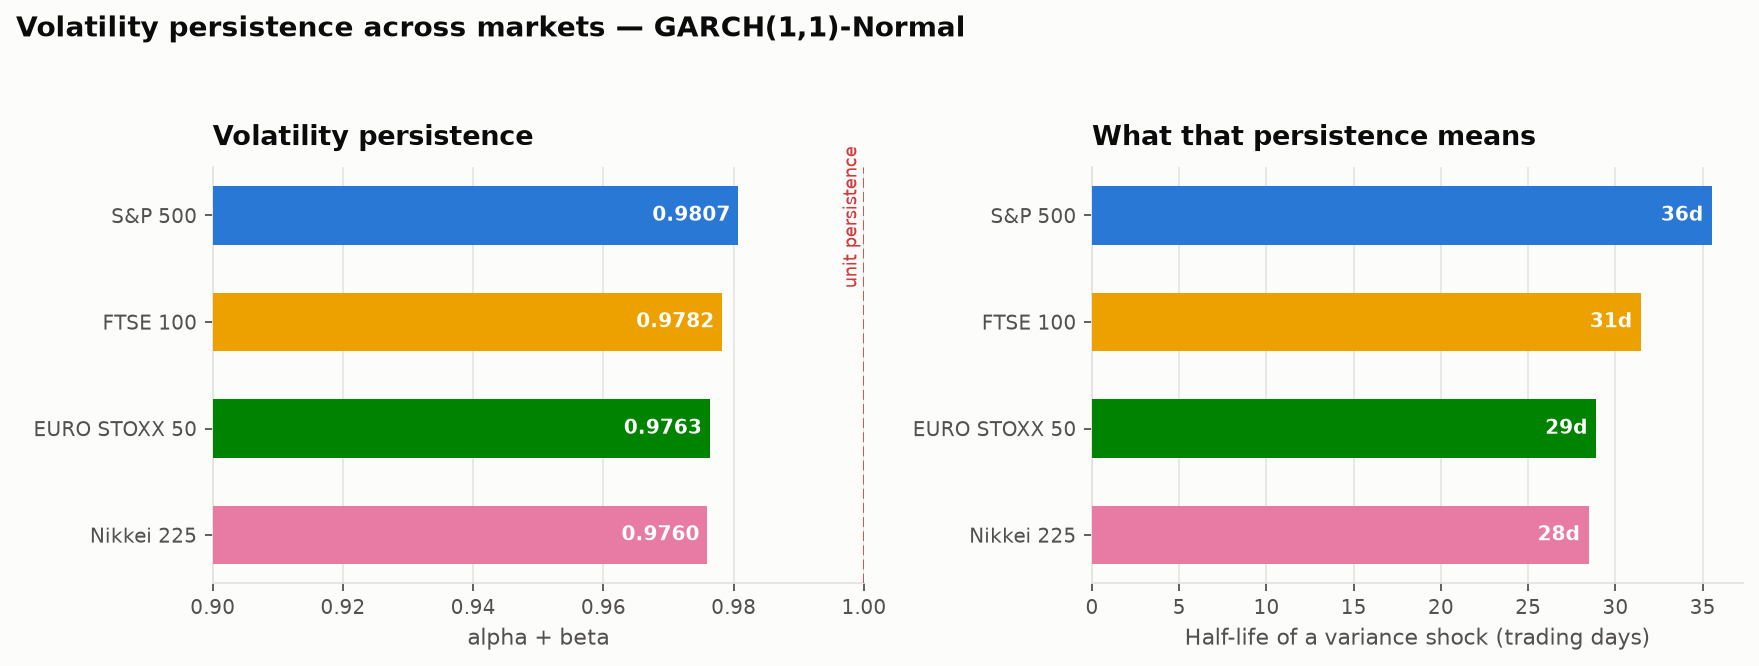

In [17]:
display(Image(M.plot_persistence_comparison(params, "GARCH(1,1)-Normal")))

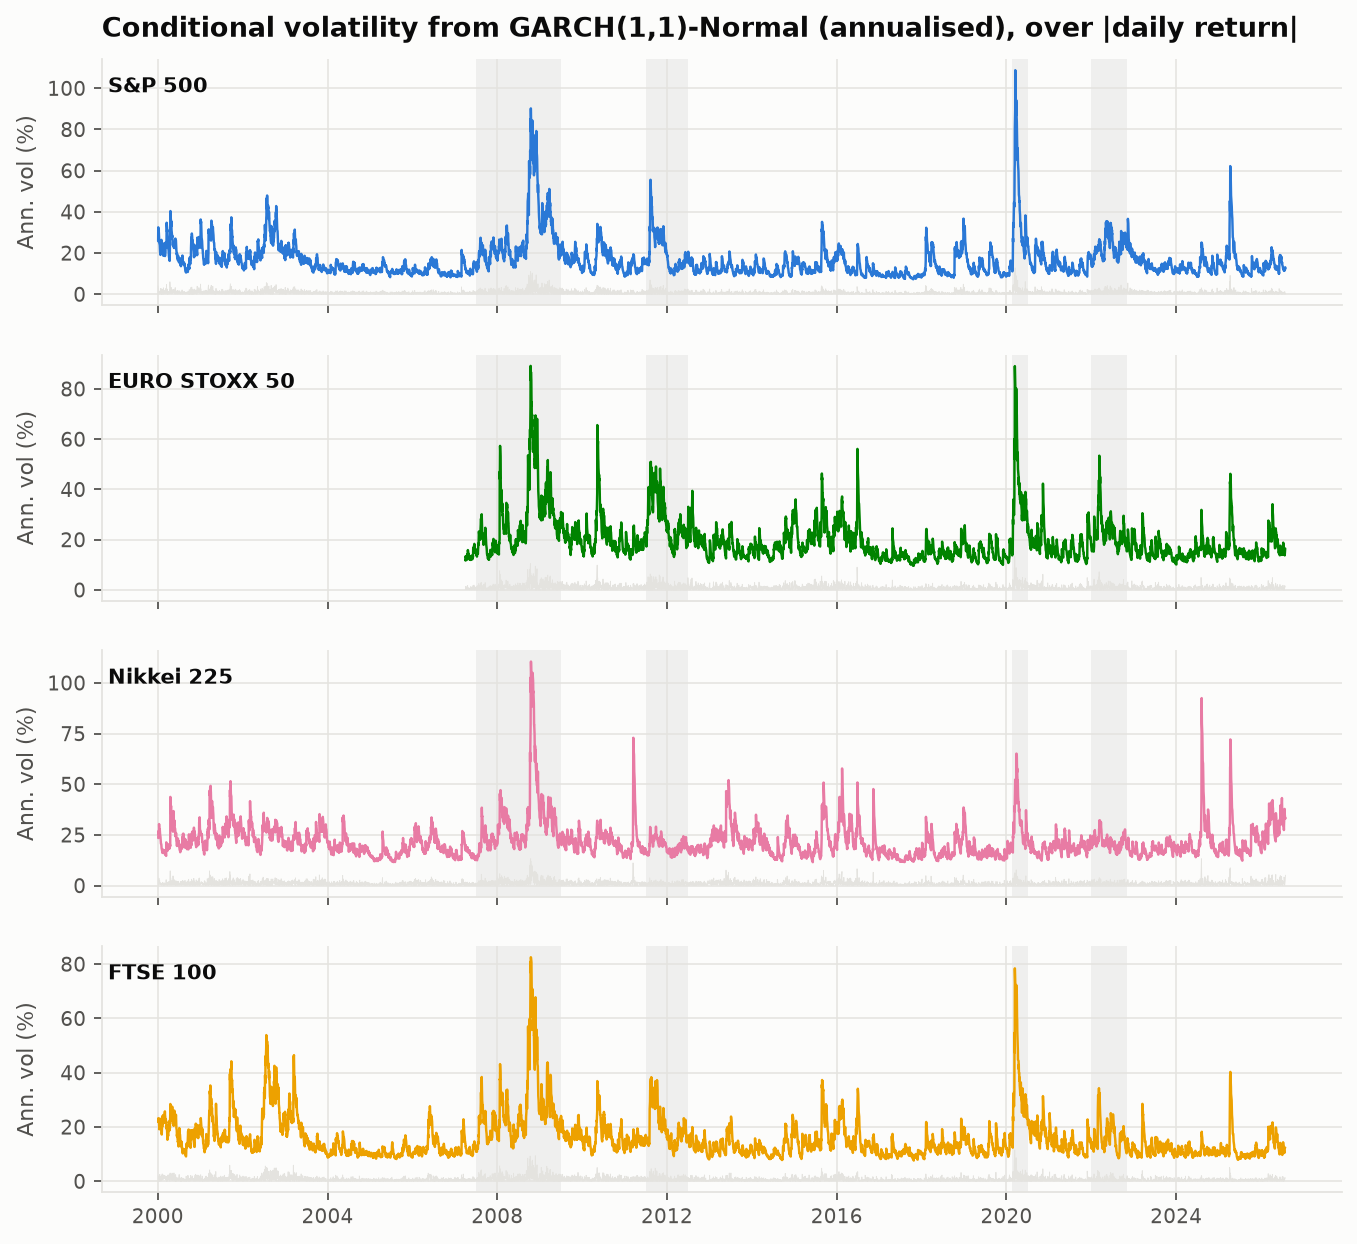

In [18]:
display(Image(M.plot_conditional_volatility(returns, fits, "GARCH(1,1)-Normal")))

### 8.3 Do crisis periods show clear spikes?

Rather than eyeballing the chart, average the fitted conditional volatility inside each
crisis window and compare it to calm periods.

In [19]:
regimes = M.regime_table(fits, "GARCH(1,1)-Normal")
regimes

,Calm periods,Global financial crisis,Euro sovereign debt crisis,COVID-19 crash,Inflation / rates shock,Peak / calm ratio
S&P 500,14.7965,29.1318,20.6213,42.5093,22.9008,2.8729
EURO STOXX 50,17.5144,28.7512,28.3359,40.5968,23.3924,2.3179
Nikkei 225,20.9519,31.9863,19.5945,32.6731,21.5937,1.5594
FTSE 100,14.3637,27.0721,19.9954,36.3289,16.6110,2.5292


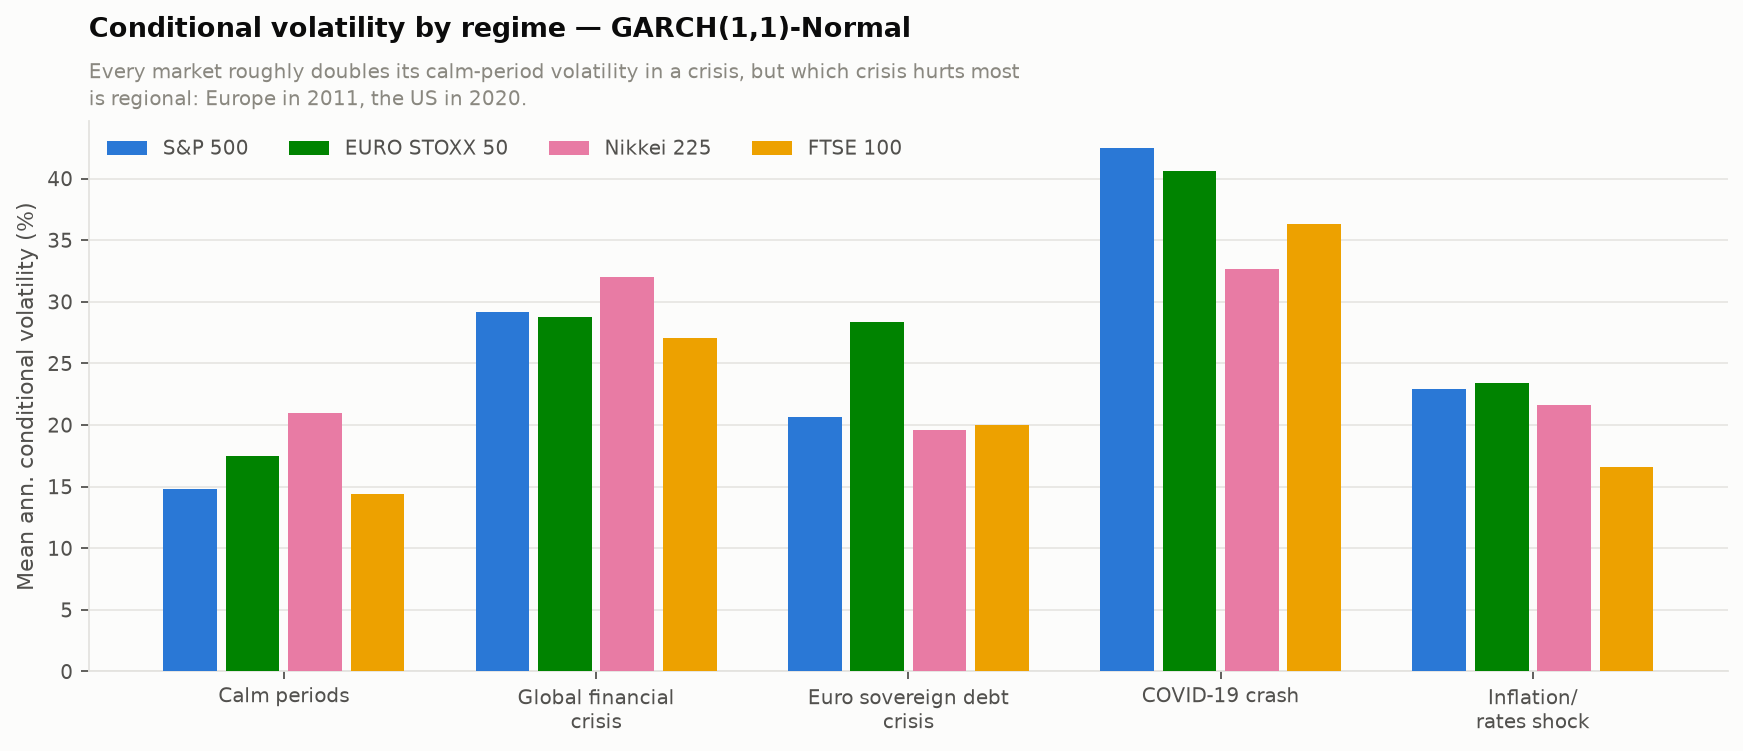

In [20]:
display(Image(M.plot_volatility_by_regime(regimes, "GARCH(1,1)-Normal")))

---
## 9. Model evaluation

### 9.1 AIC / BIC comparison

Both criteria reward fit and penalise parameters; BIC penalises harder. Lower is better.

In [21]:
comparison = M.model_comparison(fits)
comparison[["Params", "Log-lik", "AIC", "BIC", "AIC rank", "BIC rank"]]

Params      Log-lik         AIC         BIC  \
Index         Model                                                            
EURO STOXX 50 EGARCH(1,1)-t           5  -7,470.9270 14,951.8541 14,984.2774   
              GARCH(1,1)-Normal       4  -7,609.3933 15,226.7866 15,252.7253   
              GARCH(1,1)-skewt        6  -7,464.4611 14,940.9222 14,979.8302   
              GARCH(1,1)-t            5  -7,474.1067 14,958.2135 14,990.6368   
              GJR-GARCH(1,1)-t        6  -7,375.8737 14,763.7475 14,802.6555   
FTSE 100      EGARCH(1,1)-t           5  -8,843.3521 17,696.7041 17,730.7594   
              GARCH(1,1)-Normal       4  -8,951.5548 17,911.1096 17,938.3538   
              GARCH(1,1)-skewt        6  -8,817.3388 17,646.6776 17,687.5440   
              GARCH(1,1)-t            5  -8,838.1937 17,686.3874 17,720.4427   
              GJR-GARCH(1,1)-t        6  -8,740.5644 17,493.1289 17,533.9952   
Nikkei 225    EGARCH(1,1)-t           5 -10,858.7048 21,727.4095 21,761.3112   
              GARCH(1,1)-Normal       4 -10,967.1945 21,942.3889 21,969.5102   
              GARCH(1,1)-skewt        6 -10,852.6883 21,717.3766 21,758.0585   
              GARCH(1,1)-t            5 -10,863.0813 21,736.1626 21,770.0643   
              GJR-GARCH(1,1)-t        6 -10,808.8695 21,629.7389 21,670.4209   
S&P 500       EGARCH(1,1)-t           5  -9,034.8633 18,079.7265 18,113.7602   
              GARCH(1,1)-Normal       4  -9,179.4020 18,366.8039 18,394.0308   
              GARCH(1,1)-skewt        6  -8,998.0657 18,008.1314 18,048.9718   
              GARCH(1,1)-t            5  -9,022.6283 18,055.2567 18,089.2903   
              GJR-GARCH(1,1)-t        6  -8,906.6683 17,825.3367 17,866.1770   

                                 AIC rank  BIC rank  
Index         Model                                  
EURO STOXX 50 EGARCH(1,1)-t             3         3  
              GARCH(1,1)-Normal         5         5  
              GARCH(1,1)-skewt          2         2  
              GARCH(1,1)-t              4         4  
              GJR-GARCH(1,1)-t          1         1  
FTSE 100      EGARCH(1,1)-t             4         4  
              GARCH(1,1)-Normal         5         5  
              GARCH(1,1)-skewt          2         2  
              GARCH(1,1)-t              3         3  
              GJR-GARCH(1,1)-t          1         1  
Nikkei 225    EGARCH(1,1)-t             3         3  
              GARCH(1,1)-Normal         5         5  
              GARCH(1,1)-skewt          2         2  
              GARCH(1,1)-t              4         4  
              GJR-GARCH(1,1)-t          1         1  
S&P 500       EGARCH(1,1)-t             4         4  
              GARCH(1,1)-Normal         5         5  
              GARCH(1,1)-skewt          2         2  
              GARCH(1,1)-t              3         3  
              GJR-GARCH(1,1)-t          1         1

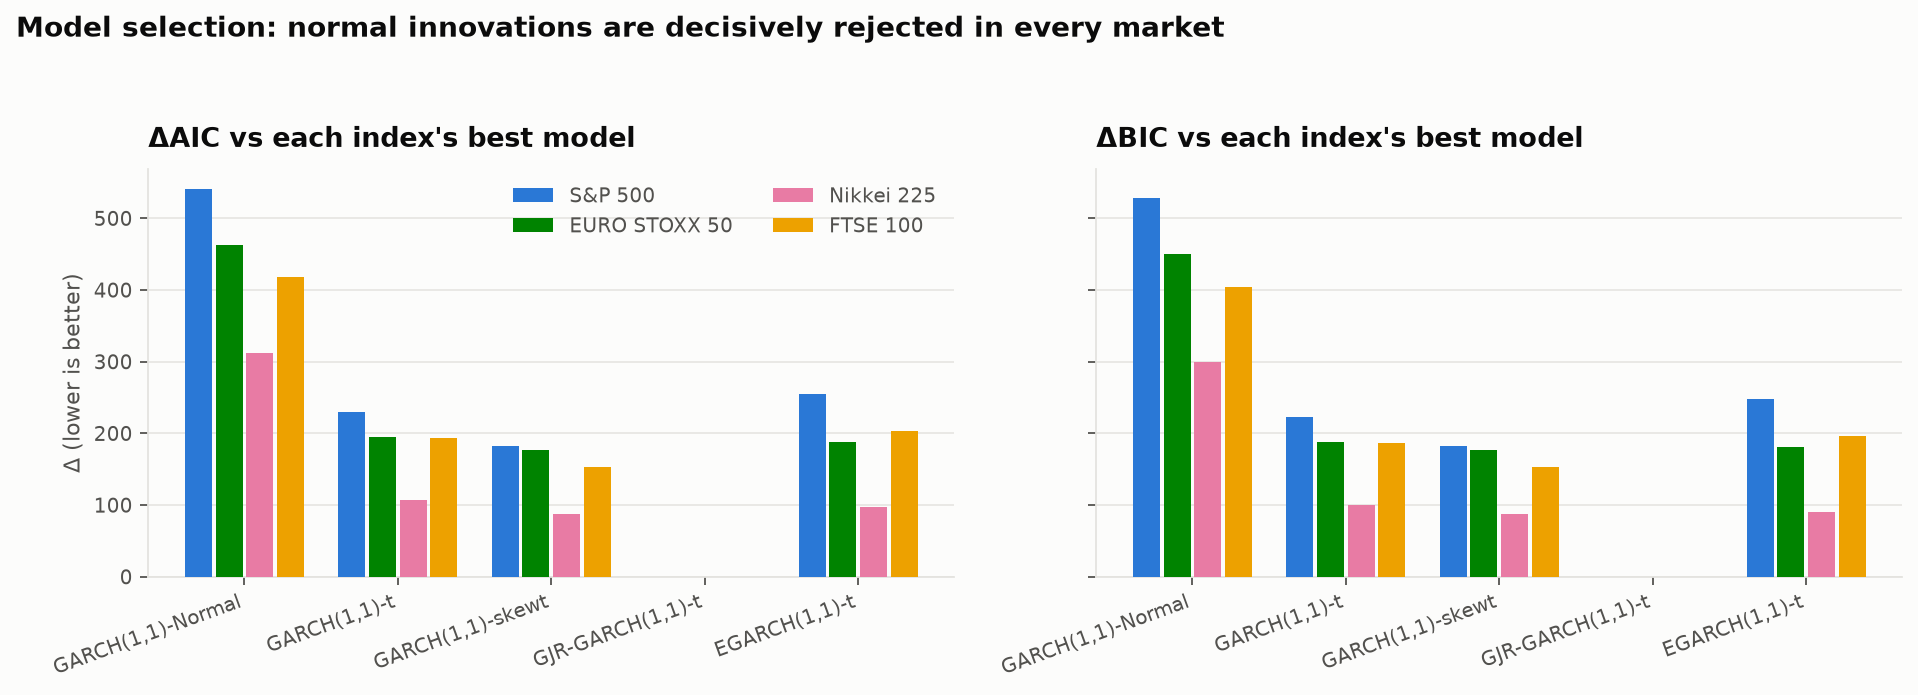

In [22]:
display(Image(M.plot_information_criteria(comparison)))

In [23]:
pd.DataFrame({
    "Best by AIC": M.best_models(comparison, "AIC"),
    "Best by BIC": M.best_models(comparison, "BIC"),
})

,Best by AIC,Best by BIC
Index,,
EURO STOXX 50,"GJR-GARCH(1,1)-t","GJR-GARCH(1,1)-t"
FTSE 100,"GJR-GARCH(1,1)-t","GJR-GARCH(1,1)-t"
Nikkei 225,"GJR-GARCH(1,1)-t","GJR-GARCH(1,1)-t"
S&P 500,"GJR-GARCH(1,1)-t","GJR-GARCH(1,1)-t"


**Does Student-t beat normal errors?** Decisively — in every market, and by a margin far
larger than the one-parameter penalty. But the bigger single improvement comes from
**GJR-GARCH**, which wins on both criteria in all four markets.

In [24]:
# What the leverage term is actually doing.
M.parameter_table(fits, "GJR-GARCH(1,1)-t")[["omega", "alpha", "gamma", "beta", "alpha+beta", "nu (t dof)"]]

,omega,alpha,gamma,beta,alpha+beta,nu (t dof)
Index,,,,,,
S&P 500,0.0185,0.0000,0.2043,0.8814,0.9836,6.8936
EURO STOXX 50,0.0383,0.0000,0.2225,0.8687,0.9800,6.3601
Nikkei 225,0.0602,0.0300,0.1448,0.8675,0.9699,8.2583
FTSE 100,0.0233,0.0000,0.1935,0.8787,0.9754,8.4870


Look at `alpha` in the GJR fits: it collapses to **zero** for three of the four indices.
The model is saying that a positive shock of any size leaves tomorrow's volatility
essentially unchanged, and *only* negative shocks raise it. The news impact curve makes
this visible.

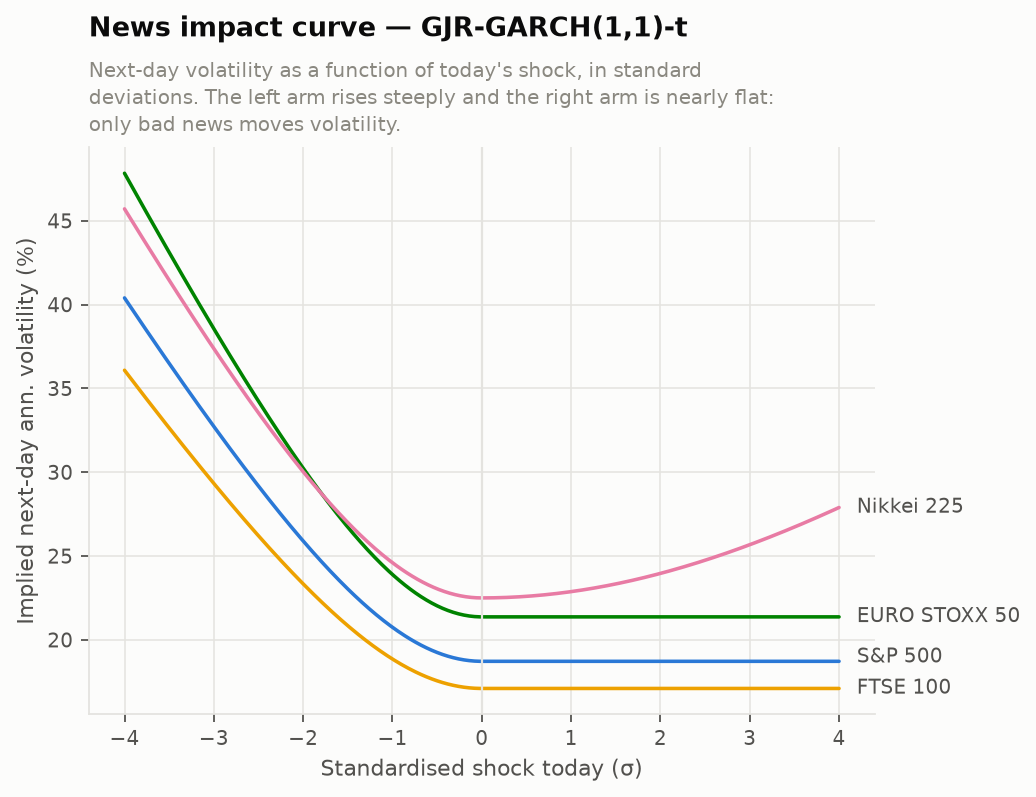

In [25]:
display(Image(M.plot_news_impact(fits, "GJR-GARCH(1,1)-t")))

---
## 10. Robustness: is the persistence ranking an artefact of the sample?

EURO STOXX 50 starts in 2007, so it misses the dot-com aftermath that the other three
include. Refit everything on the window all four cover.

In [26]:
common = M.common_sample(returns)
print(f"Common sample starts {common.index.min().date()} ({len(common):,} rows)")

fits_common = M.fit_all(common, specs=[s for s in C.MODEL_SPECS
                                       if s["label"] in {"GARCH(1,1)-Normal", "GARCH(1,1)-t"}])
pers = M.persistence_summary(fits, fits_common, "GARCH(1,1)-Normal")
pers

Common sample starts 2007-04-02 (5,025 rows)


,alpha+beta (full),Half-life (full),alpha+beta (common),Half-life (common),Difference
Index,,,,,
S&P 500,0.9807,35.5454,0.9787,32.1983,-0.0020
EURO STOXX 50,0.9763,28.9130,0.9763,28.9130,0.0000
Nikkei 225,0.9760,28.4776,0.9672,20.7801,-0.0088
FTSE 100,0.9782,31.4714,0.9727,25.0805,-0.0055


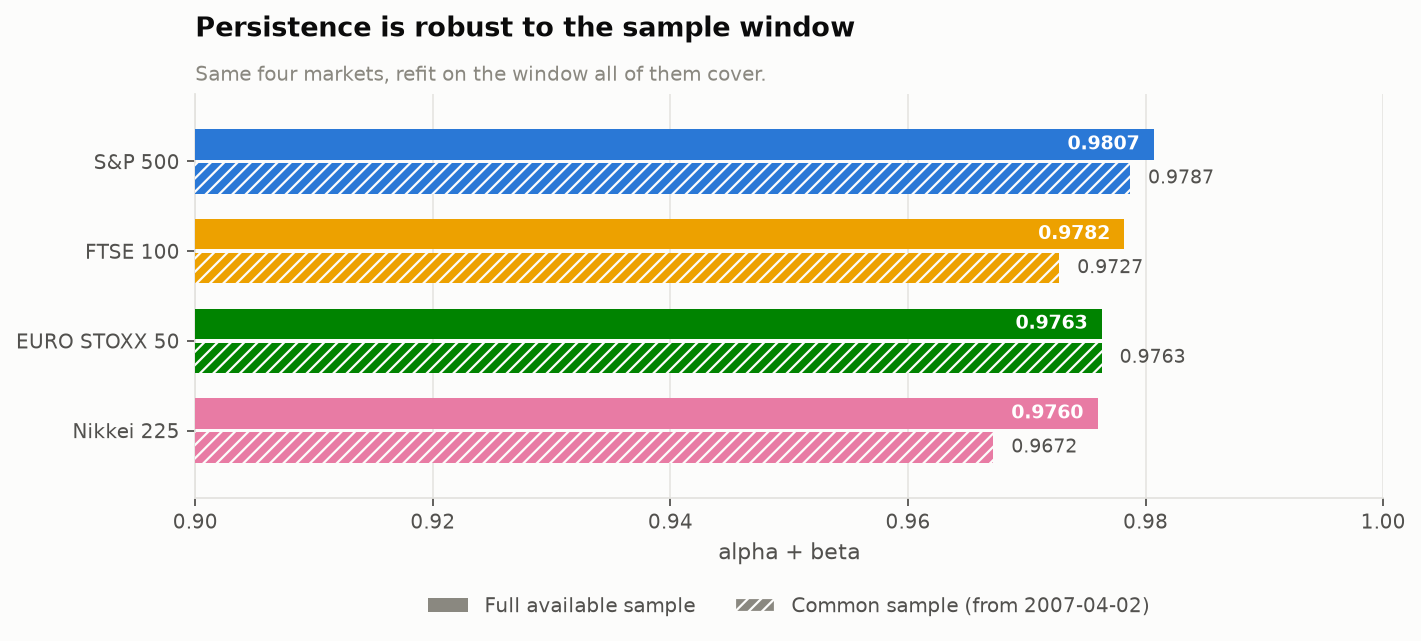

In [27]:
display(Image(M.plot_persistence_full_vs_common(pers, common.index.min())))

---
## 11. Residual diagnostics

If the model captured the dynamics, the standardised residuals
$z_t = \varepsilon_t / \sigma_t$ should be roughly i.i.d.:

- no autocorrelation in $z_t$ (the **mean** equation is adequate),
- no autocorrelation in $z_t^2$ and no ARCH-LM effect (the **variance** equation is adequate),
- a distribution matching the assumed innovation law.

In [28]:
tests = G.residual_tests(fits, "GARCH(1,1)-Normal")
tests

,LB(20) z,p (z),LB(20) z²,p (z²),ARCH-LM(20),p (ARCH-LM),Skew(z),Ex. kurtosis(z),JB p
Index,,,,,,,,,
S&P 500,33.9490,0.0265,20.7712,0.4107,20.5340,0.4250,-0.5347,1.7402,0.0000
EURO STOXX 50,14.1617,0.8222,19.8778,0.4656,20.4196,0.4320,-0.3822,2.0262,0.0000
Nikkei 225,11.2540,0.9394,20.3786,0.4345,20.7986,0.4091,-0.3495,1.3665,0.0000
FTSE 100,16.5978,0.6789,22.6669,0.3054,22.8026,0.2986,-0.4093,1.4419,0.0000


In [29]:
G.residual_test_summary(tests)

,No autocorrelation in z,No autocorrelation in z²,No remaining ARCH,Residuals normal
Index,,,,
S&P 500,fail,pass,pass,fail
EURO STOXX 50,pass,pass,pass,fail
Nikkei 225,pass,pass,pass,fail
FTSE 100,pass,pass,pass,fail


**Are standardised residuals still autocorrelated?** In $z^2$, no — GARCH(1,1) removes
the clustering everywhere (all p > 0.05, ARCH-LM likewise). But the Jarque-Bera test
still rejects normality of $z$: even after standardising, the residuals have fat tails.
That is the direct motivation for Student-t innovations.

One genuine failure: the **S&P 500** rejects on $LB(20)$ of $z$ itself. That is a
*mean*-equation problem, not a variance problem, so the fix is a richer mean model.

In [30]:
t_spec = next(s for s in C.MODEL_SPECS if s["label"] == "GARCH(1,1)-t")
M.mean_model_robustness(returns, t_spec)

,LB(20) p — Constant,BIC — Constant,LB(20) p — AR(1),BIC — AR(1)
Index,,,,
S&P 500,0.0259,"18,089.2903",0.1276,"18,069.4943"
EURO STOXX 50,0.8434,"14,990.6368",0.8710,"14,989.8045"
Nikkei 225,0.9391,"21,770.0643",0.7143,"21,769.5154"
FTSE 100,0.6784,"17,720.4427",0.4734,"17,717.3631"


Adding a single AR(1) term lifts the S&P's Ljung-Box p-value from 0.03 to 0.13 and
*improves* BIC, confirming the diagnosis. The other three indices neither need it nor
are harmed by it.

In [31]:
G.compare_residual_acf(fits, [s["label"] for s in C.MODEL_SPECS])

,"GARCH(1,1)-Normal","GARCH(1,1)-t","GARCH(1,1)-skewt","GJR-GARCH(1,1)-t","EGARCH(1,1)-t"
Index,,,,,
S&P 500,0.4107,0.2474,0.2461,0.6118,0.0300
EURO STOXX 50,0.4656,0.2630,0.2451,0.4700,0.0963
Nikkei 225,0.4345,0.0717,0.0842,0.4620,0.0000
FTSE 100,0.3054,0.1386,0.1189,0.5810,0.0043


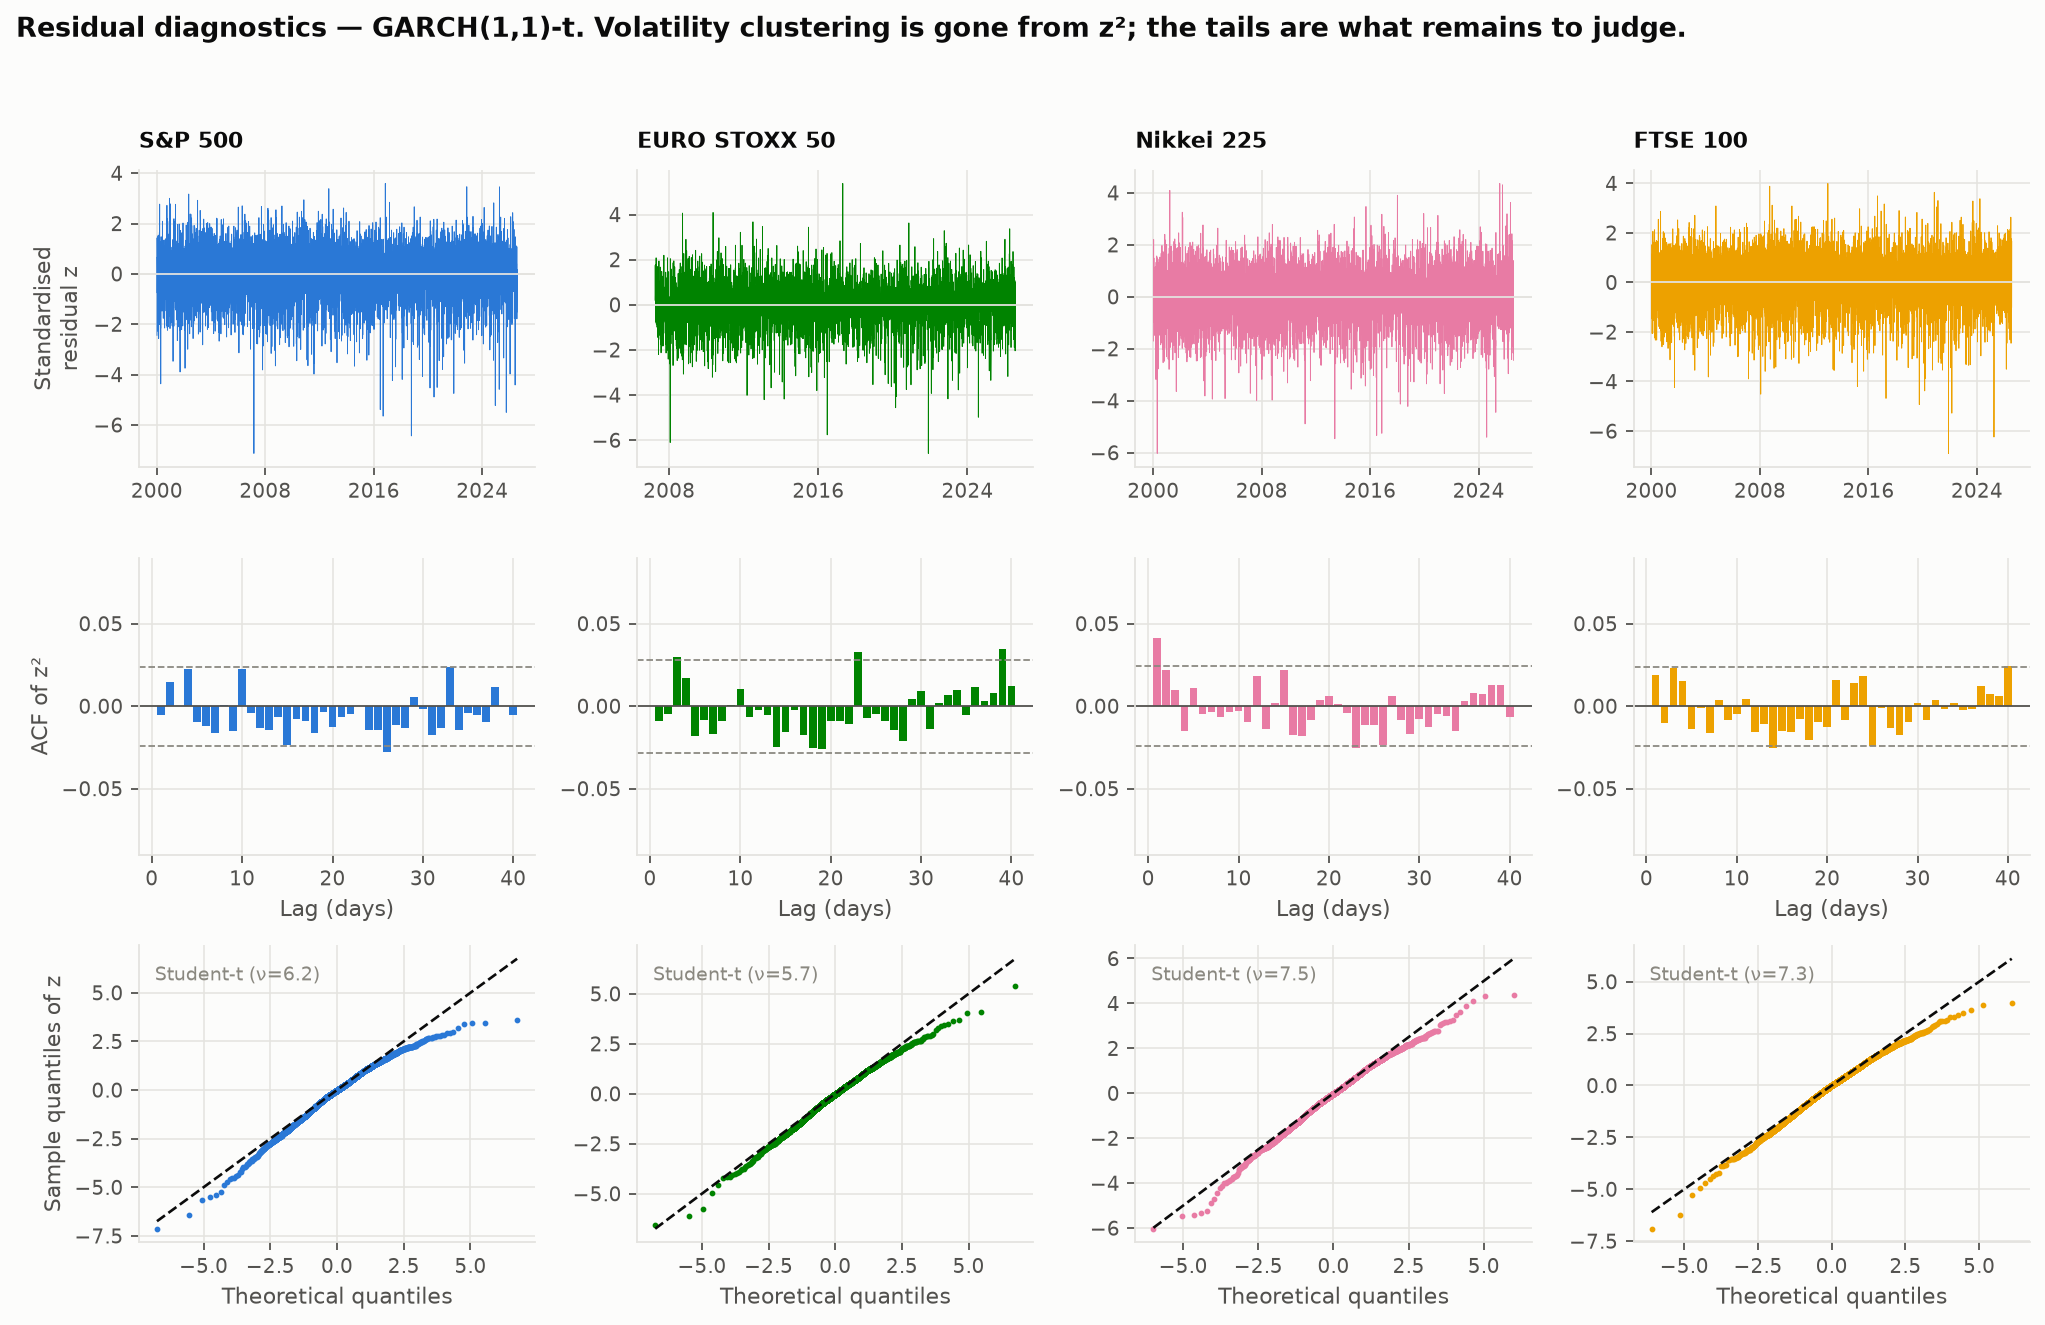

In [32]:
display(Image(G.plot_residual_diagnostics(fits, "GARCH(1,1)-t")))

---
## 12. Volatility forecasting

Multi-step variance forecasts mean-revert toward the long-run level
$\bar{\sigma}^2 = \omega / (1 - \alpha - \beta)$, at a speed set by persistence.

In [33]:
forecasts = M.volatility_forecast(fits, "GARCH(1,1)-Normal", horizon=60)
forecasts.iloc[[0, 4, 9, 19, 39, 59]]

,S&P 500,EURO STOXX 50,Nikkei 225,FTSE 100
Horizon (days),,,,
1,11.7848,16.7545,41.9715,13.7934
5,12.3770,17.3522,40.6665,14.1290
10,13.0221,17.9995,39.1526,14.4996
20,14.0683,19.0337,36.4856,15.1082
40,15.5058,20.3993,32.3893,15.9472
60,16.4077,21.2007,29.5919,16.4647


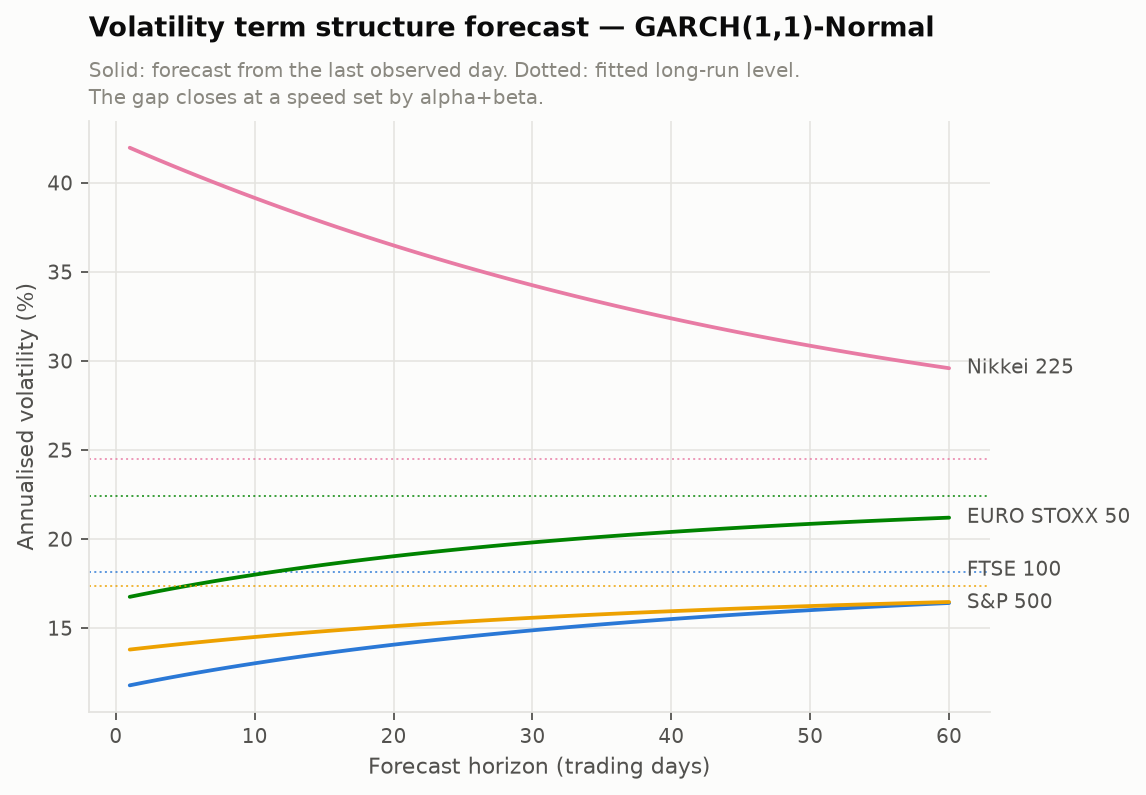

In [34]:
display(Image(M.plot_volatility_forecast(fits, forecasts, params, "GARCH(1,1)-Normal")))

---
## 13. Out-of-sample VaR backtest

The real test of a volatility model is whether it works on data it has never seen.

**Design.** Expanding estimation window, refit every 10 trading days, one-step-ahead
forecasts only. Between refits the parameters are frozen but the variance recursion keeps
running on *realised* returns, so no forecast uses future information.

**Benchmark.** Rolling 500-day historical simulation — an empirical quantile with no
volatility model at all.

**Tests.** Kupiec (is the breach *rate* right?), Christoffersen independence (are breaches
*clustered*?), and the joint conditional-coverage test.

In [35]:
%%time
var_specs = [s for s in C.MODEL_SPECS
             if s["label"] in {"GARCH(1,1)-Normal", "GARCH(1,1)-t", "GJR-GARCH(1,1)-t"}]

var_frames = {}
for t in returns.columns:
    r = D.series_for_model(returns, t)
    for spec in var_specs:
        var_frames[(t, spec["label"])] = V.rolling_var_forecast(r, spec)
    var_frames[(t, "Historical simulation")] = V.historical_simulation_var(r)

print(f"{len(var_frames)} VaR series, out-of-sample from {C.VAR_OOS_START}")

16 VaR series, out-of-sample from 2016-01-01
CPU times: user 43.1 s, sys: 2.73 s, total: 45.9 s
Wall time: 46 s


In [36]:
bt = V.backtest_table(var_frames)
bt[["Obs", "Expected breaches", "Actual breaches", "Breach rate",
    "Kupiec p", "Independence p", "Cond. coverage p", "Verdict"]]

Obs  Expected breaches  \
Index         Level Model                                            
EURO STOXX 50 1%    GARCH(1,1)-Normal      2653            26.5300   
                    GARCH(1,1)-t           2653            26.5300   
                    GJR-GARCH(1,1)-t       2653            26.5300   
                    Historical simulation  2653            26.5300   
              5%    GARCH(1,1)-Normal      2653           132.6500   
                    GARCH(1,1)-t           2653           132.6500   
                    GJR-GARCH(1,1)-t       2653           132.6500   
                    Historical simulation  2653           132.6500   
FTSE 100      1%    GARCH(1,1)-Normal      2667            26.6700   
                    GARCH(1,1)-t           2667            26.6700   
                    GJR-GARCH(1,1)-t       2667            26.6700   
                    Historical simulation  2667            26.6700   
              5%    GARCH(1,1)-Normal      2667           133.3500   
                    GARCH(1,1)-t           2667           133.3500   
                    GJR-GARCH(1,1)-t       2667           133.3500   
                    Historical simulation  2667           133.3500   
Nikkei 225    1%    GARCH(1,1)-Normal      2581            25.8100   
                    GARCH(1,1)-t           2581            25.8100   
                    GJR-GARCH(1,1)-t       2581            25.8100   
                    Historical simulation  2581            25.8100   
              5%    GARCH(1,1)-Normal      2581           129.0500   
                    GARCH(1,1)-t           2581           129.0500   
                    GJR-GARCH(1,1)-t       2581           129.0500   
                    Historical simulation  2581           129.0500   
S&P 500       1%    GARCH(1,1)-Normal      2655            26.5500   
                    GARCH(1,1)-t           2655            26.5500   
                    GJR-GARCH(1,1)-t       2655            26.5500   
                    Historical simulation  2655            26.5500   
              5%    GARCH(1,1)-Normal      2655           132.7500   
                    GARCH(1,1)-t           2655           132.7500   
                    GJR-GARCH(1,1)-t       2655           132.7500   
                    Historical simulation  2655           132.7500   

                                           Actual breaches  Breach rate  \
Index         Level Model                                                 
EURO STOXX 50 1%    GARCH(1,1)-Normal                   49       0.0185   
                    GARCH(1,1)-t                        38       0.0143   
                    GJR-GARCH(1,1)-t                    34       0.0128   
                    Historical simulation               31       0.0117   
              5%    GARCH(1,1)-Normal                  134       0.0505   
                    GARCH(1,1)-t                       149       0.0562   
                    GJR-GARCH(1,1)-t                   133       0.0501   
                    Historical simulation              133       0.0501   
FTSE 100      1%    GARCH(1,1)-Normal                   57       0.0214   
                    GARCH(1,1)-t                        42       0.0157   
                    GJR-GARCH(1,1)-t                    38       0.0142   
                    Historical simulation               34       0.0127   
              5%    GARCH(1,1)-Normal                  127       0.0476   
                    GARCH(1,1)-t                       139       0.0521   
                    GJR-GARCH(1,1)-t                   140       0.0525   
                    Historical simulation              133       0.0499   
Nikkei 225    1%    GARCH(1,1)-Normal                   58       0.0225   
                    GARCH(1,1)-t                        38       0.0147   
                    GJR-GARCH(1,1)-t                    38       0.0147   
                    Historical simulation               33       0.0128   
             

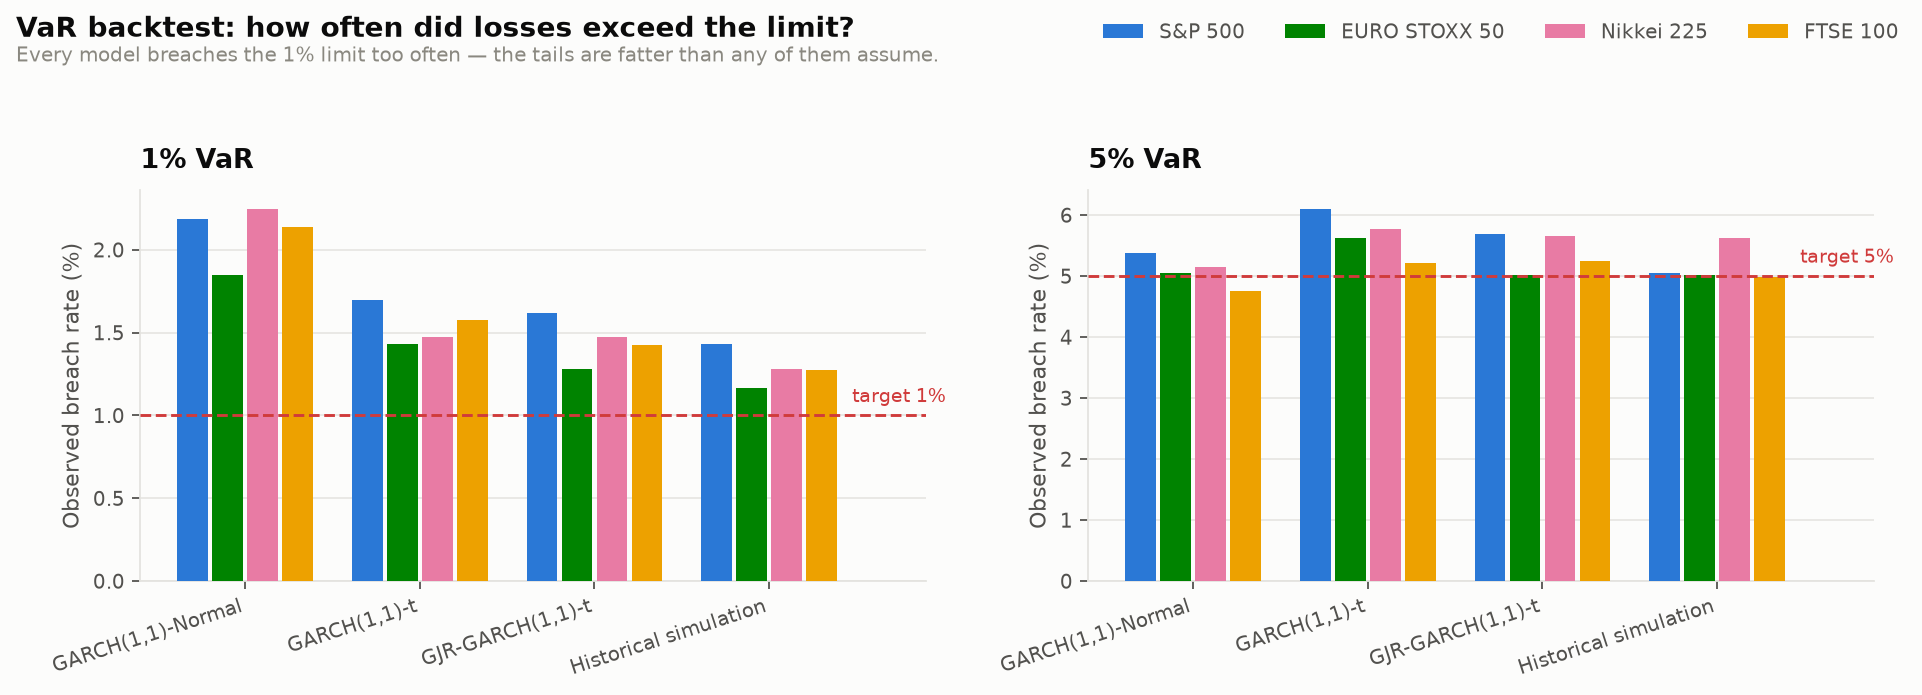

In [37]:
display(Image(V.plot_breach_rates(bt)))

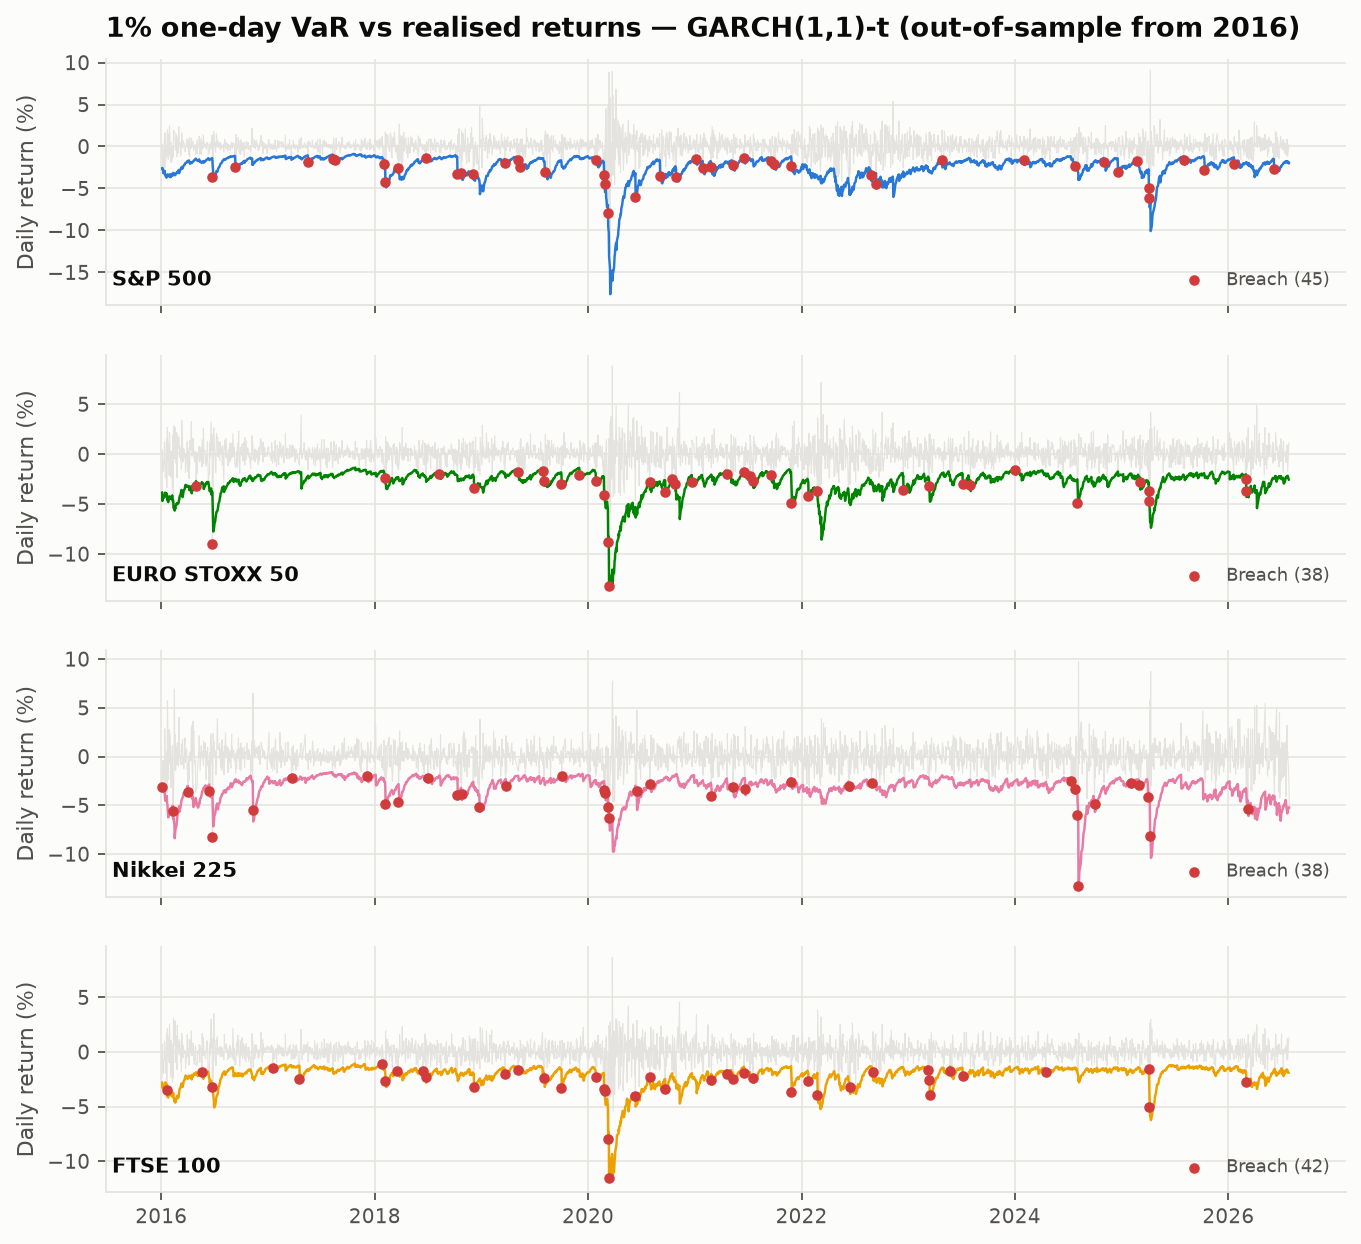

In [38]:
display(Image(V.plot_var_exceedances(var_frames, "GARCH(1,1)-t", 0.01)))

### Reading the backtest

Compare the two failure modes:

- **Historical simulation** gets the *rate* close to right (Kupiec p often > 0.4) but its
  independence p-values are ~0.000 — breaches arrive in **clusters**, because an
  unconditional quantile cannot widen when markets turn turbulent.
- **GARCH models** pass independence comfortably (p ≈ 0.2–0.7) — breaches are spread out —
  but over-shoot the 1% rate.

That contrast *is* the value of conditional volatility modelling. A risk limit that is
breached on 40 scattered days is survivable; one breached on 12 consecutive days is how
firms fail.

Still, every model breaches the 1% limit too often (1.2–2.3% against a 1% target). Even
GARCH with Student-t innovations under-states the extreme tail — a known limitation that
argues for Extreme Value Theory or Expected Shortfall in production risk work.

---
## 14. Results and interpretation

### Which index is most volatile?

Nikkei 225 (23.5% annualised), then EURO STOXX 50 (21.8%), S&P 500 (19.3%),
FTSE 100 (17.9%).

### Which has the most persistent volatility?

The **S&P 500**, on every specification and on both the full and common samples. Its
half-life of ~36 days against the Nikkei's ~28 means a US volatility shock takes about a
week longer to fade.

The interesting part is that persistence and *level* rank differently: the Nikkei is the
most volatile market but the quickest to calm down; the S&P is the calmest of the four in
normal times yet holds onto a shock the longest.

### Do crisis periods show clear spikes?

Yes, and each crisis has a regional signature — the euro crisis hit EURO STOXX hardest
while barely moving the Nikkei; COVID hit everything at once, with the S&P peaking highest.

### Does Student-t beat normal?

Yes, everywhere and by a wide margin. But **GJR-GARCH-t beats both**, and the leverage
parameter is doing most of the work.

### Are standardised residuals still autocorrelated?

Not in $z^2$ — the volatility clustering is fully absorbed. In $z$ itself, only the S&P
rejects, which an AR(1) mean fixes.

---
## 15. Conclusion and limitations

**Limitations to be honest about:**

1. **Sample mismatch.** EURO STOXX 50 has 19 years of Yahoo history against 26 for the
   others. Section 10 shows the ranking survives, but it is a real constraint.
2. **Non-synchronous trading.** These markets close at different times, so a "same day"
   shock is not the same information set. Fine for the univariate models here; it would
   need care in a multivariate extension.
3. **Local currency.** Returns are unhedged and in local currency. A dollar investor's
   Nikkei volatility includes USD/JPY.
4. **The 1% tail is still under-modelled**, as the VaR backtest shows.
5. **Persistence is assumed constant** over 26 years. A structural break or a
   regime-switching model might fit better than one set of parameters spanning the GFC,
   COVID and the 2022 rates shock.

**Natural extensions:** Extreme Value Theory for the tail, DCC-GARCH for time-varying
cross-market correlation, realised volatility from intraday data (HAR models), and
comparing GARCH forecasts against option-implied volatility.

---
## Reproducing everything

Every figure and table in this notebook is also produced by the pipeline script:

```bash
python -m src.run_analysis
```

Outputs land in `outputs/figures/` and `outputs/tables/` (CSV + Markdown), with a
machine-readable summary in `outputs/run_summary.json`.